In [7]:
import numpy as np
import pandas as pd
import pickle, os, glob, sys, warnings, yaml, shutil
import statsmodels.stats.api as sm
import itertools

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from analysis_utils import *

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record

data_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")

In [2]:
def add_pval_corrections(df):
    '''
    Implement Benjamini-Hochberg FDR and Bonferroni corrections.
    '''
    
    # LINK TO HOW TO USE: https://tedboy.github.io/statsmodels_doc/generated/statsmodels.stats.multitest.fdrcorrection.html#statsmodels.stats.multitest.fdrcorrection
        
    for col in df.columns[df.columns.str.endswith("pval")]:
            
        # skip columns that are corrected pvals
        if "BH" not in col and "Bonferroni" not in col:
            
            # NaNs will cause the functions to fail
            df = df.loc[~pd.isnull(df[col])]
            
            # alpha argument doesn't matter because we threshold later. It's only relevant if you keep the first argument, which is a boolean of reject vs. not reject
            _, bh_pvals, _, _ = sm.multipletests(df[col], method='fdr_bh', is_sorted=False, returnsorted=False)
            _, bonferroni_pvals, _, _ = sm.multipletests(df[col], method='bonferroni', is_sorted=False, returnsorted=False)

            # add prefixes to the beginnings of the columns for the corrected p-values
            df[f"BH_{col}"] = bh_pvals
            df[f"Bonferroni_{col}"] = bonferroni_pvals
            
            # check that adjusted p-values are larger so that fewer null hypotheses (coef = 0) are rejected
            assert len(df.query(f"{col} > BH_{col}")) == 0
            assert len(df.query(f"{col} > Bonferroni_{col}")) == 0

    return df.reset_index(drop=True)

In [3]:
# feat = "rpoBC_761155_A"

# plt.hist(permute_df[feat])
# plt.axvline(coef_df.query("feature==@feat")["coef"].values[0], color='black')
# plt.show()

In [4]:
# RIF_high_conf = pd.read_csv(os.path.join(data_path, drug, "isolate_variants_fixed_annot.csv"))

# Regression Saliency Maps

In [5]:
# create plotting class
class MyCustomTranslator(BiopythonTranslator):
    """Custom translator implementing the following theme:

    - Color genes in blue
    , promoters in pink
    """

    def compute_feature_color(self, feature):
        if feature.type == "CDS":
            return "blue"
        elif feature.type == "promoter":
            return "#fbb4ae"
        else:
            return "#b3cde3"

    def compute_feature_label(self, feature):
        if feature.type == "CDS":
            return "CDS here"
        elif feature.type == "promoter":
            # text returned here is the label displayed in the figure
            return None
        else:
            return BiopythonTranslator.compute_feature_label(self, feature)

    def compute_filtered_features(self, features):
        """Only display genes """
        return [
            feature for feature in features
            if (feature.type == "gene" or feature.type=="promoter")
        ]
    
#  H37Rv full genome genbank file
record = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
print(len(record.seq))

graphic_record = MyCustomTranslator().translate_record(record)

4411532


There are no significant mutations in rpoA
Finished RIF
Finished INH
There are no significant mutations in aftB_ubiA
Finished EMB
Finished PZA
Finished LEV
Finished MXF


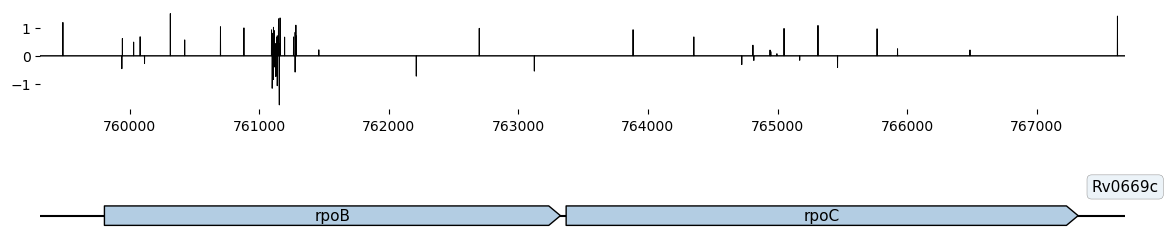

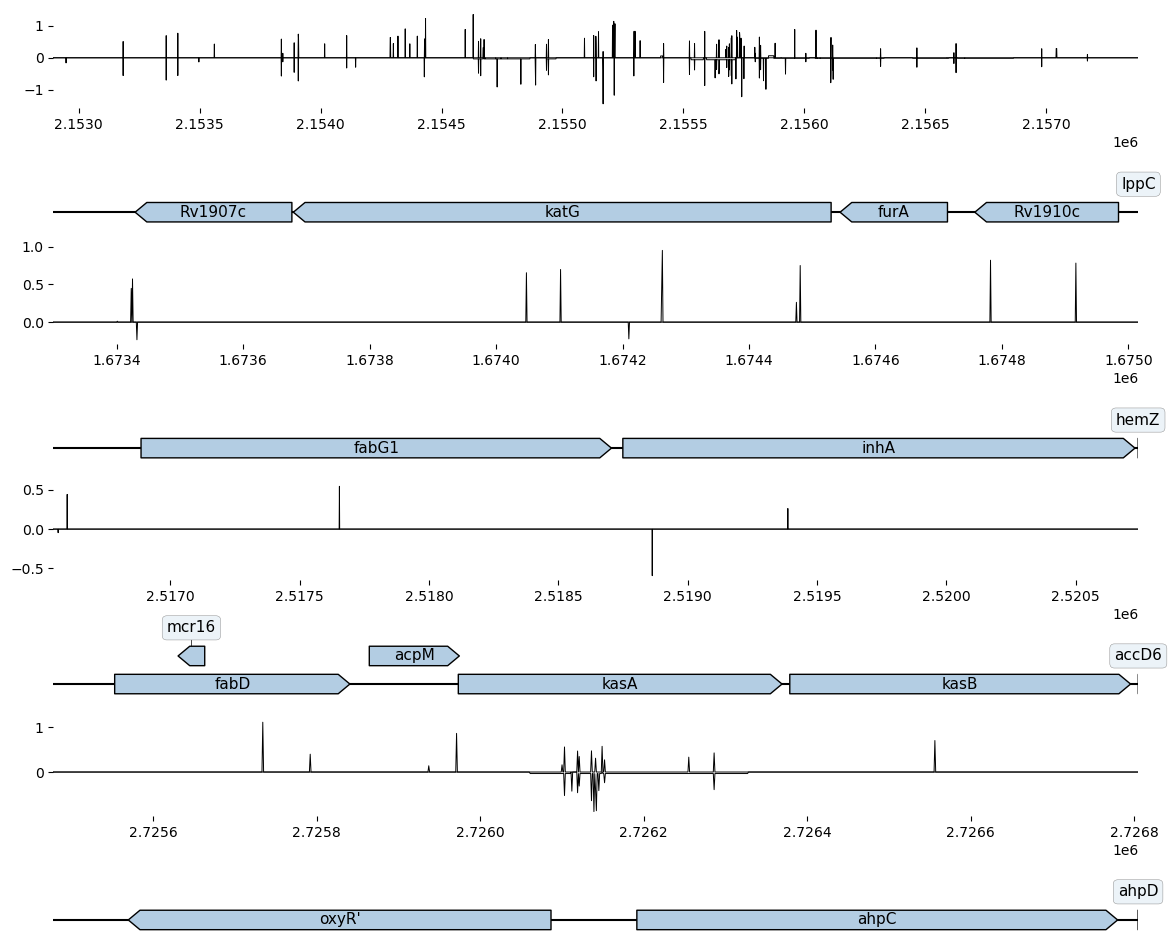

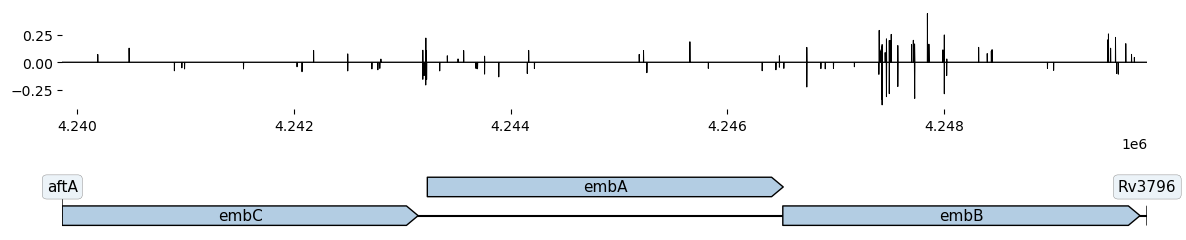

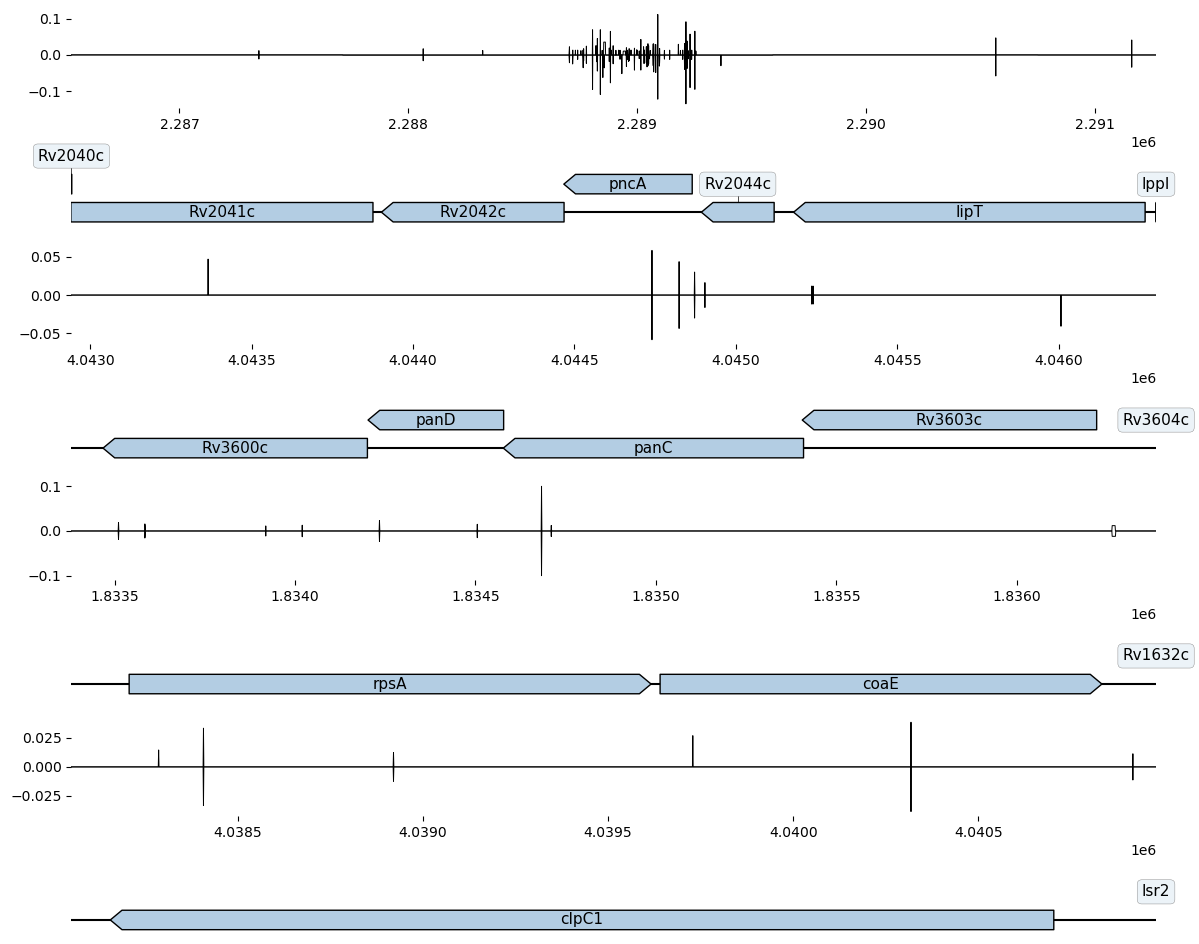

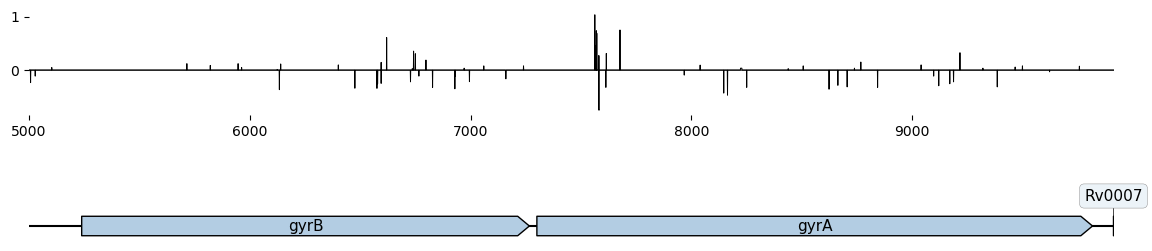

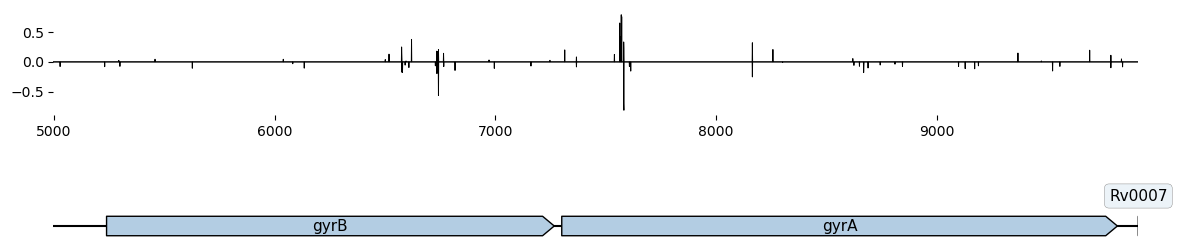

In [6]:
regression_results_drugs = {}

for drug in ["RIF", "INH", "EMB", "PZA", "LEV", "MXF"]:

    if drug == "MXF":
        config_file = f"../config_files/config_{drug.lower()}_lineage.yaml"
    else:
        config_file = f"../config_files/config_{drug.lower()}.yaml"

    kwargs = yaml.safe_load(open(config_file, "r"))
    
    output_path = kwargs["output_path"]
    ridge_dir = os.path.join(output_path, "ridge")
    coef_df = pd.read_csv(os.path.join(ridge_dir, "coef_df.csv"))
    permute_df = pd.read_csv(os.path.join(ridge_dir, "permute_df.csv"))
    assert len(permute_df) == 10
    
    drug = kwargs["drug"]
    locus_list = kwargs["locus_list"]
    fasta_dir = os.path.join(data_path, drug, "fastas")
    
    for i, row in coef_df.iterrows():
        # p-value is the proportion of permutation coefficients that are AT LEAST AS EXTREME as the test statistic
        # ONE-SIDED because we are interested in the sign of the coefficient
        if row["coef"] > 0:
            coef_df.loc[i, "pval"] = np.mean(permute_df[row["feature"]] >= row["coef"])
        else:
            coef_df.loc[i, "pval"] = np.mean(permute_df[row["feature"]] <= row["coef"])
        
    # get positions for plotting
    coef_df["gene"] = [val.split("_")[0] for val in coef_df["feature"].values]
    coef_df["pos"] = ["_".join(val.split("_")[1:-1]) if len(val) == 3 else val.split("_")[1] for val in coef_df["feature"].values]
    coef_df["nuc"] = [val.split("_")[-1] for val in coef_df["feature"].values]

    assert drug in who_variants_clean.drug.unique()
    who_highConf_sites = [val for val in who_variants_clean.query("drug==@drug & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").genome_index.str.split(",")]

    # don't make them integers because the positions in the pos column of coef_df are object type because there are indels
    who_highConf_sites = np.unique(list(itertools.chain.from_iterable(who_highConf_sites)))
    coef_df["WHO_Cat12"] = coef_df["pos"].isin(who_highConf_sites).fillna(0).astype(int)

    coef_df.to_csv(f"{drug}_saliency.csv", index=False)
    gene_coords, sense_dict = get_gene_coords(locus_list, fasta_dir)
    thresh = 0.05
    
    fig, ax = plt.subplots(gene_coords.shape[0]*2, 1, figsize=(14, 3*gene_coords.shape[0]))
    axes=ax.flatten()
    
    regression_results_by_nuc = {}
    
    for locus_idx, locus in enumerate(locus_list):
    
        # get full list of positions for each locus
        if sense_dict[locus] == "neg":
            pos_lst = np.arange(gene_coords.loc[locus].End, gene_coords.loc[locus].Start + 1)
        else:
            pos_lst = np.arange(gene_coords.loc[locus].Start, gene_coords.loc[locus].End + 1)
        
        ax_coords = axes[(locus_idx)*2+1]
        ax_saliency = axes[(locus_idx)*2]
        
        # don't plot indel scores because they don't have a position associated with them
        plot_df = coef_df.query("gene == @locus & ~feature.str.contains('indel')")
        plot_df["pos"] = plot_df["pos"].astype(int)
        
        # combine positions where there are multiple significant positive or negative scores and keep the one with the largest magnitude
        positive_df = plot_df.query("pval < @thresh & coef > 0").sort_values("coef", ascending=False).drop_duplicates("pos", keep="first")
        negative_df = plot_df.query("pval < @thresh & coef < 0").sort_values("coef", ascending=True).drop_duplicates("pos", keep="first")
    
        # add in all positions that are not in the dataframes and assign them coefficients of 0. This is so that the plotted lines don't look disjointed
        for pos in pos_lst:
            if pos not in positive_df.pos.values:
                positive_df = pd.concat([positive_df, pd.DataFrame({"pos": pos, "coef": 0}, index=[-1])], axis=0)
        
        for pos in pos_lst:
            if pos not in negative_df.pos.values:
                negative_df = pd.concat([negative_df, pd.DataFrame({"pos": pos, "coef": 0}, index=[-1])], axis=0)
    
        positive_df = positive_df.sort_values("pos", ascending=True)
        negative_df = negative_df.sort_values("pos", ascending=True)
                    
        if len(plot_df.query("pval < @thresh & coef != 0")) == 0:
            print(f"There are no significant mutations in {locus}")
            fig.delaxes(ax_coords)
            fig.delaxes(ax_saliency)
        else:
            start = np.min([int(gene_coords.loc[locus, "Start"]), int(gene_coords.loc[locus, "End"])])
            end = np.max([int(gene_coords.loc[locus, "Start"]), int(gene_coords.loc[locus, "End"])])
        
            cropped_record = graphic_record.crop((start, end))
            cropped_record.plot(ax=ax_coords, with_ruler=False)
            
            ax_coords.set_xlim(start, end)
            ax_saliency.set_xlim(start, end)
            
            ax_saliency.plot(positive_df["pos"], positive_df["coef"], linewidth=0.7, color="black")
            ax_saliency.plot(negative_df["pos"], negative_df["coef"], linewidth=0.7, color="black")
            
            sns.despine(ax=ax_saliency, top=True, right=True, left=True, bottom=True)
            ax_coords.set_ylabel("saliency")        
    
    plt.savefig(os.path.join(ridge_dir, "saliency_plots.png"), dpi=300)
    
    print(f"Finished {drug}")

In [58]:
for drug in ["RIF", "INH", "EMB", "PZA", "LEV", "MXF"]:

    who_highConf_sites = [val for val in who_variants_clean.query("drug==@drug & confidence in ['1) Assoc w R']").genome_index.str.split(",")]
    who_highConf_sites = np.unique(list(itertools.chain.from_iterable(who_highConf_sites)))
    
    df = pd.read_csv(f"{drug}_saliency.csv")
    
    found_sites = list(set(df.query("WHO_Cat12==1")["pos"]).intersection(who_highConf_sites))
    not_found = list(set(who_highConf_sites) - set(df.query("WHO_Cat12==1")["pos"]))
    print(drug)
    print(f"    Found {len(found_sites)}/{len(who_highConf_sites)} Category 1 or 2 sites. Not found: {not_found}")

RIF
    Found 16/17 Category 1 or 2 sites. Not found: ['761134']
INH
    Found 4/4 Category 1 or 2 sites. Not found: []
EMB
    Found 10/10 Category 1 or 2 sites. Not found: []
PZA
    Found 87/87 Category 1 or 2 sites. Not found: []
LEV
    Found 5/5 Category 1 or 2 sites. Not found: []
MXF
    Found 6/6 Category 1 or 2 sites. Not found: []


In [8]:
for model_path in ["RIF_rpoABC", 'INH_4Loci', 'MXF_gyrBA_lineage', 'LEV_gyrBA', 'EMB_2Loci', 'PZA_4Loci']:
    shutil.copy(os.path.join(results_path, model_path, 'ridge/saliency_plots.png'), f'/home/sak0914/{model_path}_ridge_saliency.png')

In [10]:
for model_path in ["RIF_rpoABC", 'INH_4Loci', 'MXF_gyrBA_lineage', 'LEV_gyrBA', 'EMB_2Loci', 'PZA_4Loci']:
    shutil.copy(os.path.join(results_path, model_path, 'saliency/quant/saliency_plots.png'), f'/home/sak0914/{model_path}_CNN_saliency.png')